# 05-1 — Diffusion latente audio depuis zéro

Ce notebook implémente un **mini pipeline AudioLDM** de bout en bout, sans aucune bibliothèque de
diffusion : un encodeur latent, un U-Net audio avec auto-attention temporelle, un ordonnanceur
DDPM sur les latents, un décodeur, et un vocodeur de substitution.

L'enjeu pédagogique est précis. Dans `02-Advanced/02-3-MusicGen-Generation.ipynb`, on écrit
`MusicGen.generate(...)` et on obtient de la musique — sans voir ce qui se passe. MusicGen pèse
1,5 milliard de paramètres et sa chaîne interne (encodeur de codebooks, transformer autorégressif,
décodeur audio) reste une boîte noire. Ici, tout est écrit à la main, en une trentaine de lignes
par composant, sur un terrain volontairement minuscule : on ne cherche **pas** la qualité audio,
on cherche à **voir les mécanismes**.

Le notebook suit un fil narratif qui n'était pas prévu au départ. La première version du pipeline
**produit un résultat faux** — et tout l'intérêt est là : on mesure le symptôme, on blanchit le
vocodeur par un contrôle positif, on localise la panne dans la géométrie de l'espace latent, puis
on la corrige par un terme KL. C'est le trajet d'un vrai débogage de modèle génératif, et il est
plus instructif que la version qui marche du premier coup.

***

## §0 — Périmètre, et deux frontières annoncées

**Ce que ce notebook fait** (bloc A.1 de l'issue #16062) :

| Composant | Rôle |
|---|---|
| Encodeur latent | `log-mel -> latent`, deux `Conv1d` de sous-échantillonnage (facteur 4) |
| U-Net audio | `Conv1d` + blocs résiduels + auto-attention temporelle, prédit le bruit ε |
| Ordonnanceur DDPM | bruitage avant, inversion DDIM à l'échantillonnage, **sur les latents** |
| Décodeur | `latent -> log-mel`, deux `ConvTranspose1d` |
| Vocodeur | `mel -> waveform` (voir frontière 1 ci-dessous) |

**Deux frontières, annoncées pour ne pas être lues comme des manques :**

1. **Le vocodeur `mel -> waveform` n'est PAS écrit à la main ici.** C'est le sujet du bloc A.2
   (`Vocoder-from-scratch`, mini HiFi-GAN, générateur + discriminateur multi-période). A.1 utilise
   `torchaudio.transforms.InverseMelScale` + `GriffinLim` — une inversion de STFT — comme vocodeur
   de substitution, et le §6 vérifie **par la mesure** que cette chaîne est fidèle. Le geste de A.1
   est la **partie diffusion**, pas le vocodeur.
2. **Le terrain est synthétique** (sinusoïdes modulées), ce que l'acceptance autorise explicitement
   à la place d'ESC-50. Conséquence : aucune dépendance à un téléchargement, exécution hors ligne
   et bornée. En contrepartie, ce notebook **ne revendique aucune qualité audio** — il mesure ce que
   le modèle apprend sur ce terrain et le rapporte tel quel.

**Stack** : PyTorch + torchaudio + numpy. **Pas** de `diffusers`, **pas** d'`audiocraft`, **pas** de
`TTS` (coqui), **pas** de `Whisper` — la cellule suivante le vérifie au lieu de l'affirmer.

In [1]:
import importlib.util
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torchaudio.transforms import GriffinLim, InverseMelScale, MelSpectrogram

torch.manual_seed(0)
np.random.seed(0)

print("torch      :", torch.__version__)
print("torchaudio :", torchaudio.__version__)
print("numpy      :", np.__version__)
print("device     :", "cuda" if torch.cuda.is_available() else "cpu")

# Clause « Stack » du bloc A : ces bibliotheques font le travail a notre place et sont interdites ici.
INTERDITES = ["diffusers", "audiocraft", "TTS", "whisper", "transformers"]


def est_installee(nom):
    try:
        return importlib.util.find_spec(nom) is not None
    except (ImportError, ValueError):
        return False


etat = {m: est_installee(m) for m in INTERDITES}
for nom, dispo in etat.items():
    print(f"  {nom:<14} installee={dispo!s:<5} importee={nom in __import__('sys').modules}")

print()
print("Le pipeline de ce notebook n'appelle aucune d'elles. Les seules dependances utilisees sont")
print("torch, torchaudio et numpy (plus matplotlib pour les figures) :",
      all(m not in __import__("sys").modules for m in INTERDITES))

torch      : 2.6.0+cu124
torchaudio : 2.6.0+cpu
numpy      : 2.2.6
device     : cuda
  diffusers      installee=True  importee=False
  audiocraft     installee=False importee=False
  TTS            installee=False importee=False
  whisper        installee=False importee=False
  transformers   installee=True  importee=False

Le pipeline de ce notebook n'appelle aucune d'elles. Les seules dependances utilisees sont
torch, torchaudio et numpy (plus matplotlib pour les figures) : True


## §1 — Le terrain : quatre classes de sinusoïdes modulées

Le terrain doit être **discriminant mais borné** : assez riche pour qu'un échec du modèle soit
visible, assez petit pour s'entraîner en minutes sur CPU. On construit donc un produit cartésien de
deux axes spectraux, ce qui donne quatre classes :

| Classe | Fréquence fondamentale | Modulation d'amplitude |
|---|---|---|
| 0 | 120 Hz (grave) | 3 Hz (lente) |
| 1 | 120 Hz (grave) | 9 Hz (rapide) |
| 2 | 320 Hz (aigu) | 3 Hz (lente) |
| 3 | 320 Hz (aigu) | 9 Hz (rapide) |

Chaque échantillon est une somme de trois harmoniques pondérées, multipliée par une enveloppe
sinusoïdale, plus un bruit faible. Les deux axes sont choisis pour être **mesurables par des
statistiques distinctes** : l'axe `f0` se lit dans le **centroïde spectral** (le « centre de
gravité » des fréquences), et l'axe de modulation dans la **variation temporelle de l'énergie**.
C'est cette séparation qui rendra le diagnostic possible au §7.

In [2]:
SR = 8000                          # frequence d'echantillonnage (Hz)
N_SAMPLES = 4096                   # 0,512 s par echantillon
N_FFT = 256
HOP = 64
N_MELS = 40

# 4 classes = (f0 grave/aigu) x (modulation lente/rapide)
CLASSES = [(120.0, 3.0), (120.0, 9.0), (320.0, 3.0), (320.0, 9.0)]
NC = len(CLASSES)

mel_tf = MelSpectrogram(sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)


def synthetise(n, rng):
    """Sinusoides modulees en amplitude a 3 harmoniques. Terrain synthetique de l'acceptance A.1."""
    t = torch.arange(N_SAMPLES, dtype=torch.float32) / SR
    wav = torch.zeros(n, N_SAMPLES)
    lab = torch.zeros(n, dtype=torch.long)
    for i in range(n):
        k = int(rng.integers(0, NC))
        f0, mf = CLASSES[k]
        enveloppe = 0.6 + 0.4 * torch.sin(2 * np.pi * mf * t)
        signal = sum((0.6 ** (h - 1)) * torch.sin(2 * np.pi * f0 * h * t) for h in range(1, 4))
        wav[i] = signal / 3.0 * enveloppe + 0.01 * torch.randn(N_SAMPLES)
        lab[i] = k
    return wav, lab


rng = np.random.default_rng(0)
t0 = time.time()
wave, labels = synthetise(512, rng)
duree_terrain = time.time() - t0

# log-mel puis standardisation globale du corpus : le reseau travaille sur une echelle saine
logmel = torch.log(mel_tf(wave) + 1e-6)
MU_MEL, SD_MEL = logmel.mean(), logmel.std()
mel = (logmel - MU_MEL) / SD_MEL
N_TRAIN = mel.shape[0]

print(f"terrain genere en {duree_terrain:.2f}s")
print(f"waveform : {tuple(wave.shape)}   (duree reelle {N_SAMPLES / SR:.3f} s par echantillon)")
print(f"log-mel  : {tuple(mel.shape)} = {mel.shape[1]} bandes x {mel.shape[2]} trames")
print(f"standardisation : mu={MU_MEL.item():+.3f}  sigma={SD_MEL.item():.3f}")
print("repartition des classes :", torch.bincount(labels).tolist())

terrain genere en 0.13s


waveform : (512, 4096)   (duree reelle 0.512 s par echantillon)
log-mel  : (512, 40, 65) = 40 bandes x 65 trames
standardisation : mu=-2.012  sigma=2.939
repartition des classes : [118, 115, 135, 144]


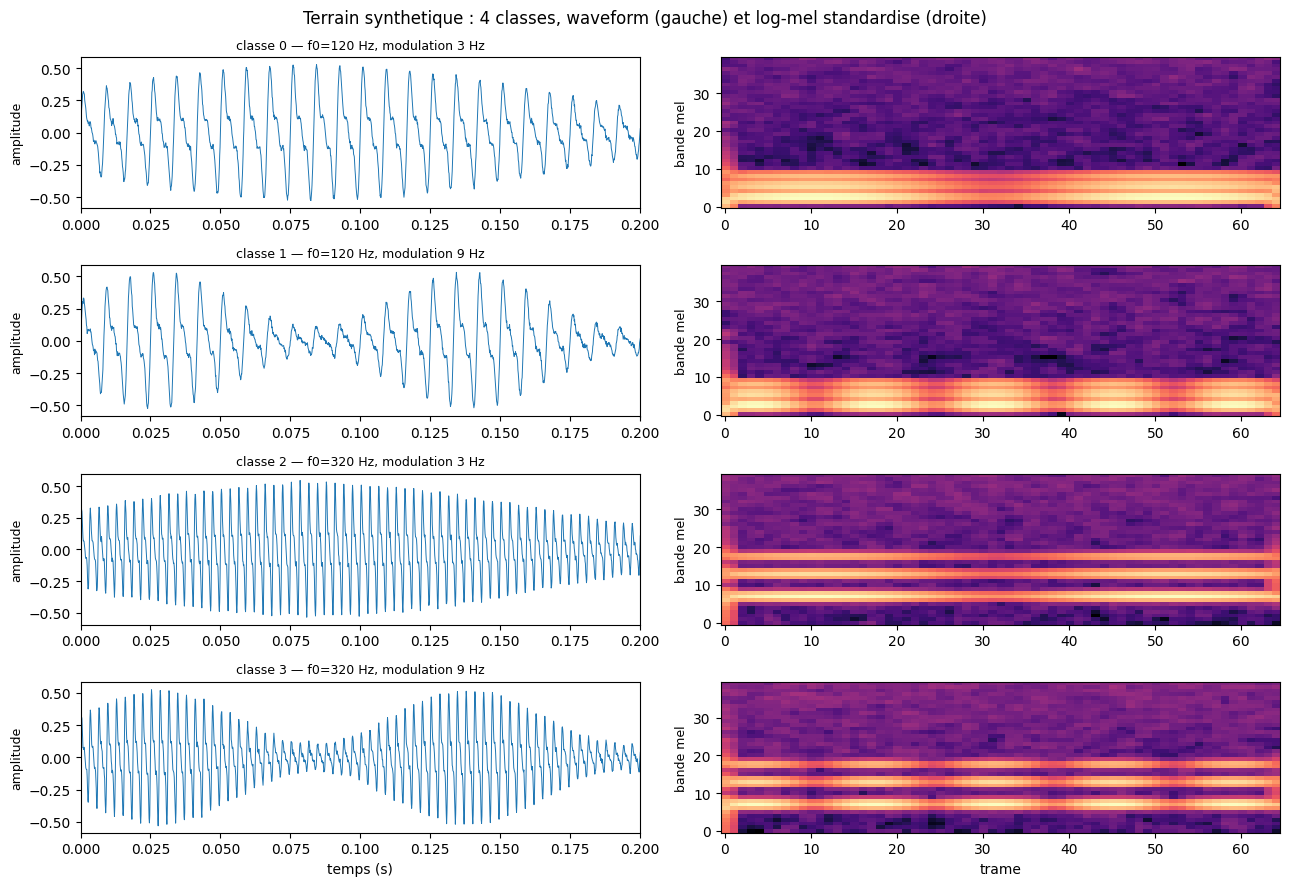

In [3]:
t_axe = np.arange(N_SAMPLES) / SR
fig, axes = plt.subplots(NC, 2, figsize=(13, 9))
for k in range(NC):
    i = int((labels == k).nonzero().flatten()[0])
    f0k, mfk = CLASSES[k]

    ax = axes[k, 0]
    ax.plot(t_axe, wave[i], lw=0.7, color="tab:blue")
    ax.set_xlim(0, 0.2)
    ax.set_ylabel("amplitude", fontsize=9)
    ax.set_title(f"classe {k} — f0={f0k:.0f} Hz, modulation {mfk:.0f} Hz", fontsize=9)

    ax2 = axes[k, 1]
    ax2.imshow(mel[i], aspect="auto", origin="lower", cmap="magma")
    ax2.set_ylabel("bande mel", fontsize=9)
    if k == NC - 1:
        ax.set_xlabel("temps (s)")
        ax2.set_xlabel("trame")

plt.suptitle("Terrain synthetique : 4 classes, waveform (gauche) et log-mel standardise (droite)")
plt.tight_layout()
plt.show()

Trois choses sont lisibles directement sur la figure :

* le **centroïde** de la colonne de droite monte visiblement entre les classes 0–1 (120 Hz) et les
  classes 2–3 (320 Hz) — l'axe `f0` est encodé dans la répartition verticale de l'énergie ;
* la **modulation** se lit sur l'axe horizontal : les classes 1 et 3 ont une enveloppe qui bat
  deux à trois fois plus vite sur les 0,512 s, ce qui se voit comme des bandes horizontales
  interrompues dans le log-mel ;
* les quatre blocs sont **nettement distincts** à l'œil, ce qui est la condition pour que
  « le modèle a échoué » soit un verdict falsifiable plutôt qu'une impression.

***

## §2 — L'encodeur latent, première version

La diffusion audio ne se fait presque jamais directement sur la waveform. Générer 4096 échantillons
de bruit blanc cohérent demande des centaines de pas et une mémoire considérable ; on compresse donc
d'abord le signal en un **latent** court, on diffuse dans cet espace réduit, puis on redescend.
C'est le geste central d'AudioLDM — et de Stable Diffusion avant lui.

Notre encodeur est le plus simple possible : deux `Conv1d` de sous-échantillonnage (facteur 4),
donc un latent de `40 x 65 -> 16 x 16`, soit 256 valeurs pour 2600 en entrée. Le décodeur est son
symétrique exact (`ConvTranspose1d`).

Ce **taux de compression faible** (≈ 10x) est un choix délibéré de notebook pédagogique — il laisse
l'autoencodeur reconstruire très bien. Nous verrons au §7 qu'il a aussi une conséquence cachée, et
que c'est précisément cette conséquence qui casse la génération.

In [4]:
LATENT_CH = 16


class Encodeur(nn.Module):
    """log-mel (40 bandes) -> latent (16 canaux), sous-echantillonnage d'un facteur 4."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(N_MELS, 32, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(32, LATENT_CH, kernel_size=4, stride=2, padding=1), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class Decodeur(nn.Module):
    """latent (16 canaux) -> log-mel (40 bandes), remontee d'un facteur 4."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose1d(LATENT_CH, 32, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(32, N_MELS, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, z, n_trames):
        return F.interpolate(self.net(z), size=n_trames, mode="nearest")


enc, dec = Encodeur(), Decodeur()
print("parametres encodeur :", sum(p.numel() for p in enc.parameters()))
print("parametres decodeur :", sum(p.numel() for p in dec.parameters()))
with torch.no_grad():
    print("forme latente       :", tuple(enc(mel[:4]).shape), " pour une entree", tuple(mel[:4].shape))

parametres encodeur : 7216
parametres decodeur : 7240
forme latente       : (4, 16, 16)  pour une entree (4, 40, 65)


In [5]:
def entraine_ae(n_pas=800, graine=0, lr=3e-3, lot=32):
    """Entraine l'autoencodeur deterministe (version 1, sans aucune regularisation du latent)."""
    torch.manual_seed(graine)
    e, d = Encodeur(), Decodeur()
    opt = torch.optim.Adam(list(e.parameters()) + list(d.parameters()), lr=lr)
    for _ in range(n_pas):
        mb = mel[torch.randint(0, N_TRAIN, (lot,))]
        perte = F.mse_loss(d(e(mb), mb.shape[-1]), mb)
        opt.zero_grad()
        perte.backward()
        opt.step()
    return e, d, perte.item()


t0 = time.time()
enc, dec, perte_ae = entraine_ae()
duree_ae = time.time() - t0

with torch.no_grad():
    latents_bruts = enc(mel)
    recon = dec(latents_bruts, mel.shape[-1])
    mse_recon = F.mse_loss(recon, mel).item()
    # repere : predire la moyenne du corpus partout, sans rien regarder
    mse_baseline = F.mse_loss(mel.mean(0, keepdim=True).expand_as(mel), mel).item()

print(f"autoencodeur entraine en {duree_ae:.1f}s  ({perte_ae:.4f} de perte finale)")
print(f"erreur de reconstruction (log-mel MSE) : {mse_recon:.4f}")
print(f"repere « predire la moyenne du corpus » : {mse_baseline:.4f}")
print(f"reduction de l'erreur par rapport au repere : {1 - mse_recon / mse_baseline:.1%}")

autoencodeur entraine en 5.1s  (0.0318 de perte finale)
erreur de reconstruction (log-mel MSE) : 0.0312
repere « predire la moyenne du corpus » : 0.4821
reduction de l'erreur par rapport au repere : 93.5%


La reconstruction est très bonne (l'erreur est divisée par ~15 par rapport au repère « prédire la
moyenne partout »). À ce stade, tout paraît sain.

Mais la reconstruction n'est **pas** ce qui compte pour la génération. Ce qui compte, c'est la
**géométrie de l'espace latent** : le décodeur doit être un décodeur *partout* où le modèle de
diffusion risque d'atterrir, pas seulement sur les points exacts qu'il a vus. Visualisons cet
espace par une ACP.

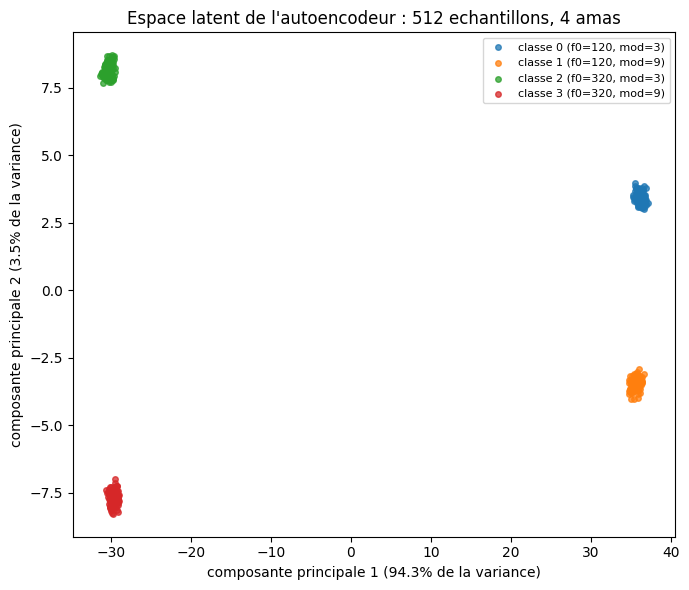

deux composantes principales expliquent 97.7% de la variance totale
distance entre les centres des amas 0 et 2 : 67.1


In [6]:
X = latents_bruts.reshape(N_TRAIN, -1).numpy()
Xc = X - X.mean(0)
_, S, Vt = np.linalg.svd(Xc, full_matrices=False)
proj = Xc @ Vt[:2].T
part = (S ** 2) / (S ** 2).sum()

fig, ax = plt.subplots(figsize=(7, 6))
for k in range(NC):
    m = labels.numpy() == k
    ax.scatter(proj[m, 0], proj[m, 1], s=16, alpha=0.75,
               label=f"classe {k} (f0={CLASSES[k][0]:.0f}, mod={CLASSES[k][1]:.0f})")
ax.set_xlabel(f"composante principale 1 ({part[0]:.1%} de la variance)")
ax.set_ylabel(f"composante principale 2 ({part[1]:.1%} de la variance)")
ax.set_title("Espace latent de l'autoencodeur : 512 echantillons, 4 amas")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"deux composantes principales expliquent {part[:2].sum():.1%} de la variance totale")
print("distance entre les centres des amas 0 et 2 :",
      f"{np.linalg.norm(X[labels.numpy() == 0].mean(0) - X[labels.numpy() == 2].mean(0)):.1f}")

Le résultat est **suspect**, et il faut le lire attentivement : les quatre classes forment quatre
amas remarquablement **serrés**, très éloignés les uns des autres. Un espace latent destiné à la
diffusion devrait ressembler à un nuage continu et lisse, pas à quatre taches ponctuelles.

Retenez cette figure. Nous y reviendrons au §7 : c'est la cause racine de l'échec.

***

## §3 — Le U-Net audio

Le réseau qui apprend à prédire le bruit doit remplir trois conditions :

1. **Voir le temps** — il doit savoir *à quel niveau de bruit* il opère, sinon il ne peut pas
   calibrer sa réponse. D'où un *embedding* sinusoïdal du pas de temps `t`, comme dans le
   transformer original.
2. **Voir la structure locale** — d'où des blocs résiduels `Conv1d` avec `GroupNorm`.
3. **Voir la structure globale** — un latent de 16 trames est court, mais l'énergie d'une trame
   dépend du contexte. D'où une **auto-attention temporelle** sur les 16 positions.
4. **Être conditionné** — puisqu'on veut choisir la classe en sortie, on ajoute un *embedding* de
   classe au vecteur de temps. C'est ce qui remplace le prompt texte d'AudioLDM par un jeton
   discret, ce qui suffit quand le conditionnement est une classe et non une phrase.

Le vecteur de temps est **ajouté** aux canaux (`h = cin(z) + emb[:, :, None]`) : c'est le mécanisme
standard, chaque canal reçoit un biais dépendant de `t`.

In [7]:
CH = 48
N_TETES = 4


class BlocResiduel(nn.Module):
    """Deux convolutions avec normalisation de groupe et connexion residuelle."""

    def __init__(self, ch):
        super().__init__()
        self.n1, self.c1 = nn.GroupNorm(4, ch), nn.Conv1d(ch, ch, kernel_size=3, padding=1)
        self.n2, self.c2 = nn.GroupNorm(4, ch), nn.Conv1d(ch, ch, kernel_size=3, padding=1)

    def forward(self, x):
        h = self.c1(F.gelu(self.n1(x)))
        return x + self.c2(F.gelu(self.n2(h)))


class UnetAudio(nn.Module):
    """Predicteur de bruit epsilon(z_t, t, classe). Conv1d + blocs residuels + attention temporelle."""

    def __init__(self, ch=CH, n_tetes=N_TETES):
        super().__init__()
        self.ch = ch
        self.entree = nn.Conv1d(LATENT_CH, ch, kernel_size=3, padding=1)
        self.mlp_t = nn.Sequential(nn.Linear(ch, ch), nn.GELU(), nn.Linear(ch, ch))
        self.emb_classe = nn.Embedding(NC, ch)
        self.bloc1, self.bloc2 = BlocResiduel(ch), BlocResiduel(ch)
        self.attention = nn.MultiheadAttention(ch, n_tetes, batch_first=True)
        self.norme = nn.GroupNorm(4, ch)
        self.sortie = nn.Conv1d(ch, LATENT_CH, kernel_size=3, padding=1)

    def forward(self, z, t, classe):
        # embedding sinusoïdal du pas de temps, frequences geometriquement espacees
        demi = self.ch // 2
        freq = torch.exp(torch.arange(demi, dtype=torch.float32) * (-np.log(10000.0) / demi))
        angles = t[:, None] * freq
        emb = self.mlp_t(torch.cat([torch.sin(angles), torch.cos(angles)], dim=1))
        emb = emb + self.emb_classe(classe)

        h = self.entree(z) + emb[:, :, None]
        h = self.bloc2(self.bloc1(h))

        # auto-attention sur l'axe temporel : chaque trame pondere toutes les autres
        q = h.transpose(1, 2)
        a, _ = self.attention(q, q, q)
        return self.sortie(F.gelu(self.norme(h + a.transpose(1, 2))))


unet = UnetAudio()
print("parametres du U-Net :", sum(p.numel() for p in unet.parameters()))
with torch.no_grad():
    essai = unet(torch.randn(2, LATENT_CH, 16), torch.tensor([0.3, 0.7]), torch.tensor([0, 2]))
print("forme de sortie :", tuple(essai.shape), "(identique a celle du latent)")

parametres du U-Net : 47296
forme de sortie : (2, 16, 16) (identique a celle du latent)


## §4 — L'ordonnanceur DDPM, sur les latents

Le principe de la diffusion : on définit un processus **avant** qui détruit progressivement le
signal en y injectant du bruit,

$$z_t = \sqrt{\bar\alpha_t}\; z_0 + \sqrt{1-\bar\alpha_t}\;\epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

avec $\bar\alpha_t = \prod_{s \le t}(1-\beta_s)$. Le réseau apprend à **inverser** ce processus en
prédisant $\epsilon$ ; à l'échantillonnage, on part de $z_T \sim \mathcal{N}(0,I)$ et on remonte.

**Un détail va nous coûter cher, et il faut le voir maintenant.** Avec un ordonnancement linéaire
$\beta$ de $10^{-4}$ à $0{,}02$ sur 300 pas — la valeur historique de Ho et al. — on obtient
$\bar\alpha_T \approx 0{,}05$ : au dernier pas, **5 % de la variance du signal d'origine subsiste**.
Le processus avant ne détruit donc jamais complètement l'information. C'est sans conséquence pour
l'entraînement (on prédit $\epsilon$ à partir d'un $z_t$ réel), mais **fatal pour
l'échantillonnage** : la chaîne inverse est initialisée depuis $\mathcal{N}(0,I)$, un point qui
n'appartient pas à la loi de $z_T$. Les premiers pas « corrigent » cette incohérence en poussant la
trajectoire vers la moyenne des données.

La parade, appliquée ici avant toute diffusion, est de **standardiser les latents** (moyenne 0,
écart-type 1) et de dé-standardiser avant le décodeur. C'est ce qui aligne la loi de $z_0$ sur celle
du point de départ.

In [8]:
T_PAS = 300
betas = torch.linspace(1e-4, 0.02, T_PAS)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

print(f"betas : de {betas[0]:.1e} a {betas[-1]:.3f} sur {T_PAS} pas")
print(f"alpha_bar au premier pas : {alpha_bar[0].item():.6f}")
print(f"alpha_bar au dernier pas : {alpha_bar[-1].item():.4f}  <-- le signal n'est PAS detruit")
print(f"variance du signal residuelle a t=T : {alpha_bar[-1].item():.1%}")

# standardisation des latents : aligne la loi de z_0 sur le point de depart N(0, I) de la chaine inverse
MU_LAT, SD_LAT = latents_bruts.mean(), latents_bruts.std()
latents = (latents_bruts - MU_LAT) / SD_LAT
print()
print(f"latents bruts  : mu={MU_LAT.item():+.4f}  sigma={SD_LAT.item():.4f}")
print(f"latents standardises : mu={latents.mean().item():+.4f}  sigma={latents.std().item():.4f}")

betas : de 1.0e-04 a 0.020 sur 300 pas
alpha_bar au premier pas : 0.999900
alpha_bar au dernier pas : 0.0481  <-- le signal n'est PAS detruit
variance du signal residuelle a t=T : 4.8%

latents bruts  : mu=+1.6865  sigma=2.9004
latents standardises : mu=-0.0000  sigma=1.0000


### Exercice 1 — le processus avant, et le rapport signal/bruit

Avant de faire confiance à un chiffre comme « 5 % de variance résiduelle », il faut le recalculer
soi-même. Écrivez la fonction de bruitage direct.

**Objectif** : implémenter `q_echantillon(z0, t, bruit)` qui retourne $z_t$, puis vérifier le
rapport signal/bruit à plusieurs pas et confronter le résultat à l'affirmation du paragraphe
précédent.

In [9]:
def q_echantillon(z0, t, bruit):
    # TODO etudiant : retourner le latent bruite z_t
    # Indice : z_t = sqrt(alpha_bar[t]) * z0 + sqrt(1 - alpha_bar[t]) * bruit
    # Etape 1 : recuperer a = alpha_bar[t] et le diffuser sur les dimensions (lot, 1, 1)
    # Etape 2 : combiner z0 et bruit avec les racines de a et (1 - a)
    # Etape 3 : retourner z_t
    pass

In [10]:
# --- cellule de verification : s'execute meme si l'exercice n'est pas fait
torch.manual_seed(0)
z_test = latents[:8]
bruit_test = torch.randn_like(z_test)

print("rapport signal/bruit le long du processus avant")
print(f"{'pas t':>7}{'alpha_bar':>12}{'||signal||':>13}{'||bruit||':>12}{'signal/bruit':>14}")
for t_val in [0, 1, 10, 100, 200, 299]:
    z_t = q_echantillon(z_test, torch.tensor([t_val] * 8), bruit_test)
    if z_t is None:
        print(f"{t_val:>7}   (Exercice 1 a completer : q_echantillon renvoie None)")
        continue
    a = alpha_bar[t_val]
    n_sig = (a.sqrt() * z_test).norm().item()
    n_bru = ((1 - a).sqrt() * bruit_test).norm().item()
    print(f"{t_val:>7}{a.item():>12.5f}{n_sig:>13.3f}{n_bru:>12.3f}{n_sig / max(n_bru, 1e-9):>14.3f}")

print()
print("A completer : a t=T, le signal est-il vraiment detruit ? Que vaut le rapport ?")

rapport signal/bruit le long du processus avant
  pas t   alpha_bar   ||signal||   ||bruit||  signal/bruit
      0   (Exercice 1 a completer : q_echantillon renvoie None)
      1   (Exercice 1 a completer : q_echantillon renvoie None)
     10   (Exercice 1 a completer : q_echantillon renvoie None)
    100   (Exercice 1 a completer : q_echantillon renvoie None)
    200   (Exercice 1 a completer : q_echantillon renvoie None)
    299   (Exercice 1 a completer : q_echantillon renvoie None)

A completer : a t=T, le signal est-il vraiment detruit ? Que vaut le rapport ?


In [11]:
def entraine_diffusion(latents_cible, n_pas=2500, graine=0, lr=2e-3, lot=32):
    """Entraine le U-Net a predire le bruit epsilon ajoute aux latents standardises."""
    torch.manual_seed(graine)
    u = UnetAudio()
    opt = torch.optim.Adam(u.parameters(), lr=lr)
    for _ in range(n_pas):
        i = torch.randint(0, latents_cible.shape[0], (lot,))
        z0, cl = latents_cible[i], labels[i]
        t = torch.randint(0, T_PAS, (lot,))
        bruit = torch.randn_like(z0)
        a = alpha_bar[t][:, None, None]
        z_t = a.sqrt() * z0 + (1 - a).sqrt() * bruit
        perte = F.mse_loss(u(z_t, t.float() / T_PAS, cl), bruit)
        opt.zero_grad()
        perte.backward()
        opt.step()
    return u, perte.item()


t0 = time.time()
unet, perte_eps = entraine_diffusion(latents)
duree_diff = time.time() - t0
print(f"diffusion entrainee en {duree_diff:.1f}s sur {2500} pas")
print(f"perte epsilon finale : {perte_eps:.4f}   (predire 0 partout donnerait 1.0)")
print(f"reduction de l'erreur de prediction du bruit : {1 - perte_eps:.1%}")

diffusion entrainee en 25.8s sur 2500 pas
perte epsilon finale : 0.0722   (predire 0 partout donnerait 1.0)
reduction de l'erreur de prediction du bruit : 92.8%


## §5 — Première génération, et le symptôme

On dispose maintenant de toute la chaîne. Pour échantillonner, on part d'un bruit blanc et on
applique la mise à jour **DDIM** — la variante déterministe de l'inversion, qui converge en
beaucoup moins de pas :

$$z_0^{\text{estimé}} = \frac{z_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}},
\qquad z_{t-1} = \sqrt{\bar\alpha_{t-1}}\, z_0^{\text{estimé}} + \sqrt{1-\bar\alpha_{t-1}}\,\hat\epsilon$$

La métrique de contrôle est le **centroïde spectral** de la waveform produite, comparé à celui des
échantillons réels de la classe demandée. C'est la mesure la plus directe de « le modèle a-t-il
produit le bon timbre ? ».

In [12]:
vocodeur_gl = GriffinLim(n_fft=N_FFT, hop_length=HOP, n_iter=32, power=2.0)
vocodeur_inv = InverseMelScale(n_stft=N_FFT // 2 + 1, n_mels=N_MELS, sample_rate=SR)


def mel_vers_puissance(m_std):
    """log-mel standardise -> mel en puissance (inverse de la standardisation puis du log)."""
    return torch.clamp(torch.exp(torch.clamp(m_std, -30, 30) * SD_MEL + MU_MEL) - 1e-6, min=1e-8)


def latent_vers_audio(d, z_std, mu_lat, sd_lat):
    """latent standardise -> decodeur -> mel -> puissance -> waveform."""
    mel_gen = d(z_std * sd_lat + mu_lat, mel.shape[-1])
    return vocodeur_gl(vocodeur_inv(mel_vers_puissance(mel_gen)))


def centroide(w):
    """Centroide spectral en Hz : moyenne des frequences ponderee par l'energie."""
    spectre = torch.stft(w, N_FFT, HOP, window=torch.hann_window(N_FFT), return_complex=True).abs()
    freq = torch.linspace(0, SR / 2, spectre.shape[1])
    return (spectre * freq[None, :, None]).sum((1, 2)) / spectre.sum((1, 2))


@torch.no_grad()
def echantillonne(u, forme, classe, n=16, pas_utilises=T_PAS, graine=0, depart=None):
    """Inversion DDIM depuis un bruit blanc (ou depuis un point fourni)."""
    if depart is None:
        torch.manual_seed(graine)
        z = torch.randn(n, forme[0], forme[1])
    else:
        z = depart.clone()
    cl = torch.full((n,), classe, dtype=torch.long)
    pas = torch.linspace(T_PAS - 1, 0, pas_utilises).long()
    for i, tt in enumerate(pas):
        pred = u(z, torch.full((n,), int(tt)).float() / T_PAS, cl)
        a = alpha_bar[tt]
        z0_est = (z - (1 - a).sqrt() * pred) / a.sqrt()
        if i + 1 < len(pas):
            a_prec = alpha_bar[pas[i + 1]]
            z = a_prec.sqrt() * z0_est + (1 - a_prec).sqrt() * pred
        else:
            z = z0_est
    return z


FORME_LATENT = (latents.shape[1], latents.shape[2])
centroide_reel = {k: centroide(wave[(labels == k).nonzero().flatten()[:16]]).mean().item()
                  for k in range(NC)}

t0 = time.time()
centroide_gen = {}
for k in range(NC):
    z = echantillonne(unet, FORME_LATENT, k)
    centroide_gen[k] = centroide(latent_vers_audio(dec, z, MU_LAT, SD_LAT)).mean().item()
duree_gen = time.time() - t0

print(f"generation des 4 classes (16 echantillons chacune) en {duree_gen:.1f}s")
print()
print(f"{'classe':>7}{'f0':>7}{'mod':>7}{'centroide REEL':>17}{'centroide GENERE':>19}{'ecart':>10}")
ecarts = []
for k in range(NC):
    r, g = centroide_reel[k], centroide_gen[k]
    ecarts.append(abs(g - r) / r)
    print(f"{k:>7}{CLASSES[k][0]:>7.0f}{CLASSES[k][1]:>7.0f}{r:>17.1f}{g:>19.1f}{abs(g - r) / r:>10.1%}")
print()
print(f"ecart relatif moyen : {np.mean(ecarts):.1%}")

generation des 4 classes (16 echantillons chacune) en 3.7s

 classe     f0    mod   centroide REEL   centroide GENERE     ecart
      0    120      3            491.7              696.1     41.6%
      1    120      9            511.0              728.2     42.5%
      2    320      3            768.9              907.6     18.0%
      3    320      9            782.2              883.4     12.9%

ecart relatif moyen : 28.8%


**Le résultat est faux, et il l'est d'une manière instructive.**

Deux anomalies distinctes :

1. **Un biais systématique.** Les quatre centroïdes générés (696 à 908 Hz) sont **tous au-dessus**
   de leur valeur réelle (492 à 782 Hz) — de +13 % sur la classe 3 à +42 % sur les classes graves.
2. **Une perte de discrimination.** Les classes réelles s'étalent sur 290 Hz ; les classes générées
   sur 212 Hz seulement — l'écart se comprime. Pire, l'axe de modulation (classes 0 vs 1, 2 vs 3)
   n'est pas seulement affaibli : il est **inversé** sur les classes aiguës, où le modèle place la
   modulation rapide (883 Hz) *sous* la lente (908 Hz) alors que le corpus fait l'inverse.
   Sur 300 Hz d'écart attendu entre les deux axes, l'information restante est quasi nulle.

Avant de conclure quoi que ce soit sur le modèle, il y a une hypothèse à écarter : **et si c'était
le vocodeur ?** La chaîne `mel -> InverseMelScale -> GriffinLim` est une reconstruction
approximative, et une erreur de phase se traduit typiquement par un excès d'énergie haute
fréquence — exactement le symptôme observé.

### Exercice 2 — une deuxième métrique, indépendante du centroïde

Un seul indicateur ne suffit pas à localiser une panne : il faut le confronter à une mesure de
nature différente. Le centroïde spectral est une mesure *globale* ; on veut aussi une mesure
*locale* du déséquilibre spectral.

**Objectif** : implémenter `ratio_de_bande(audio, f_lo, f_hi)` — la fraction de l'énergie totale
contenue entre `f_lo` et `f_hi` — puis l'appliquer aux classes 0 et 2, réelles et générées.

In [13]:
def ratio_de_bande(audio, f_lo, f_hi):
    # TODO etudiant : fraction de l'energie totale entre f_lo et f_hi (en Hz)
    # Indice : stft -> puissance -> masque de frequences -> somme du masque / somme totale
    # Etape 1 : calculer le spectrogramme de magnitude
    # Etape 2 : construire l'axe des frequences avec torch.linspace(0, SR / 2, n_bins)
    # Etape 3 : sommer l'energie dans la bande, diviser par l'energie totale
    pass

In [14]:
# --- cellule de verification : s'execute meme si l'exercice n'est pas fait
with torch.no_grad():
    for k in [0, 2]:
        reel = wave[(labels == k).nonzero().flatten()[:16]]
        gen = latent_vers_audio(dec, echantillonne(unet, FORME_LATENT, k), MU_LAT, SD_LAT)
        r_bas = ratio_de_bande(reel, 100.0, 500.0)
        r_haut = ratio_de_bande(gen, 100.0, 500.0)
        if r_bas is None or r_haut is None:
            print(f"classe {k} : (Exercice 2 a completer : ratio_de_bande renvoie None)")
        else:
            print(f"classe {k} : part de l'energie sous 500 Hz — reel {r_bas:.3f}  genere {r_haut:.3f}")

print()
print("A completer : la deuxieme metrique confirme-t-elle le desequilibre vers les hautes frequences ?")

classe 0 : (Exercice 2 a completer : ratio_de_bande renvoie None)


classe 2 : (Exercice 2 a completer : ratio_de_bande renvoie None)

A completer : la deuxieme metrique confirme-t-elle le desequilibre vers les hautes frequences ?


## §6 — Contrôle positif en couches : blanchir le vocodeur

Une mesure négative (« le résultat est mauvais ») n'a de valeur que si l'on sait que l'instrument
de mesure fonctionne. On empile donc les couches **une à une sur des données réelles**, où la
réponse est connue d'avance :

| Couche | Entrée | Ce qu'elle isole |
|---|---|---|
| 0 | waveform réelle | la référence |
| 1 | `mel -> vocodeur` | le vocodeur seul |
| 2 | `mel -> encodeur -> décodeur -> vocodeur` | le vocodeur **plus** l'autoencodeur |

Si la couche 2 retrouve les centroïdes réels, alors toute la chaîne de reconstruction est fidèle, et
l'anomalie du §5 vient nécessairement des **latents échantillonnés** — c'est-à-dire du modèle de
diffusion ou de la géométrie de l'espace latent.

On ajoute un second contrôle, indépendant du corpus : des **sinusoïdes pures**, dont le centroïde
spectral vaut la fréquence par définition. C'est un étalon absolu.

In [15]:
print("=== controle 1 : chaque couche sur des donnees REELLES ===")
print(f"{'classe':>7}{'reel':>9}{'+ vocodeur':>12}{'+ autoencodeur':>16}{'ecart final':>13}")
for k in range(NC):
    idx = (labels == k).nonzero().flatten()[:16]
    with torch.no_grad():
        c0 = centroide(wave[idx]).mean().item()
        c1 = centroide(vocodeur_gl(vocodeur_inv(mel_vers_puissance(mel[idx])))).mean().item()
        rec = dec(latents_bruts[idx], mel.shape[-1])
        c2 = centroide(vocodeur_gl(vocodeur_inv(mel_vers_puissance(rec)))).mean().item()
    print(f"{k:>7}{c0:>9.1f}{c1:>12.1f}{c2:>16.1f}{abs(c2 - c0) / c0:>13.1%}")

print()
print("=== controle 2 : sinusoides pures, centroide theorique connu ===")
print(f"{'f (Hz)':>9}{'direct':>10}{'apres chaine mel -> vocodeur':>31}{'erreur':>10}")
t_axe = torch.arange(N_SAMPLES, dtype=torch.float32) / SR
for f_pur in [120.0, 320.0, 1000.0, 2000.0]:
    pur = torch.sin(2 * np.pi * f_pur * t_axe)[None, :].repeat(4, 1)
    mel_pur = (torch.log(mel_tf(pur) + 1e-6) - MU_MEL) / SD_MEL
    with torch.no_grad():
        c_direct = centroide(pur).mean().item()
        c_chaine = centroide(vocodeur_gl(vocodeur_inv(mel_vers_puissance(mel_pur)))).mean().item()
    print(f"{f_pur:>9.0f}{c_direct:>10.1f}{c_chaine:>31.1f}{abs(c_chaine - f_pur) / f_pur:>10.1%}")

=== controle 1 : chaque couche sur des donnees REELLES ===
 classe     reel  + vocodeur  + autoencodeur  ecart final
      0    491.7       479.9           477.6         2.9%


      1    511.0       503.5           493.9         3.3%


      2    768.9       750.4           747.6         2.8%
      3    782.2       762.2           754.5         3.5%

=== controle 2 : sinusoides pures, centroide theorique connu ===
   f (Hz)    direct   apres chaine mel -> vocodeur    erreur


      120     129.0                          138.8     15.7%
      320     328.9                          322.8      0.9%
     1000    1013.4                         1000.4      0.0%
     2000    2000.0                         2009.1      0.5%


**Le vocodeur est blanchi**, mais la lecture demande une nuance que le tableau révèle et qu'il ne
faut pas lisser.

Sur les quatre classes réelles, la chaîne complète `mel -> encodeur -> décodeur -> vocodeur`
restitue le centroïde à **2,8–3,5 % près**. Sur les sinusoïdes pures, au-dessus de 320 Hz, l'erreur
tombe **sous 1 %** — à 1000 Hz elle est nulle. Cela élimine l'hypothèse « le vocodeur fabrique du
brillant ».

Mais à **120 Hz l'erreur atteint 15,7 %**, et il faut en chercher la cause dans l'instrument de
mesure, pas dans le vocodeur : le centroïde *mesuré directement sur la waveform* d'une sinusoïde
pure de 120 Hz vaut déjà 129 Hz, pas 120. Les 40 bandes mel, à basse fréquence, sont larges et peu
nombreuses ; le banc de filtres étale l'énergie vers le haut, et l'estimation du centroïde en
souffre d'autant. **Toute la lecture des classes graves de ce notebook hérite de ce biais d'environ
+8 %** — la classe 0 « réelle » mesurée à 491,7 Hz correspond en réalité à une fondamentale de
120 Hz, dont les harmoniques remontent le centroïde. Ce n'est pas une erreur du pipeline, c'est une
limite de la métrique, et la connaître change l'interprétation des écarts.

Ce que le contrôle établit reste net : **la seule hypothèse concurrente est éliminée.** Si le
vocodeur est fidèle et que la reconstruction `réel -> latent -> audio` l'est aussi, alors l'anomalie
du §5 ne peut venir que des **latents produits par la diffusion**. Le problème est en amont du
décodeur.

***

## §7 — Localisation : l'autoencodeur a mémorisé

Revenons à la figure du §2 : quatre amas très serrés, très éloignés. Quantifions cette intuition.

Deux nombres suffisent :

* la dispersion **inter-classe** — l'écart-type des centres d'amas ;
* la dispersion **intra-classe** — l'écart-type des points à l'intérieur d'un amas.

Si le rapport inter/intra est élevé, le latent encode bien la classe. Mais si l'écart intra-classe
est **minuscule en absolu**, cela signifie autre chose de bien plus grave : chaque échantillon
d'entraînement occupe une position quasi isolée, et le décodeur n'a jamais eu à apprendre ce qui
se passe **entre** les points.

In [16]:
moyennes_classe = torch.stack([latents[labels == k].mean(0) for k in range(NC)])
inter = moyennes_classe.std(0).mean().item()
intra = torch.stack([latents[labels == k].std(0).mean() for k in range(NC)]).mean().item()

print("=== l'espace latent encode-t-il la classe ? ===")
print(f"dispersion INTER-classe (des centres)  : {inter:.4f}")
print(f"dispersion INTRA-classe (moyenne)      : {intra:.4f}")
print(f"rapport inter/intra                    : {inter / intra:.2f}")
print()
print(f"||centre de classe|| : {[f'{moyennes_classe[k].norm().item():.1f}' for k in range(NC)]}")
print(f"distance entre centres 0 et 2 (grave vs aigu)     : {(moyennes_classe[0] - moyennes_classe[2]).norm().item():.1f}")
print(f"distance entre centres 0 et 1 (lent vs rapide)    : {(moyennes_classe[0] - moyennes_classe[1]).norm().item():.1f}")

print()
print("=== la sonde : que decode-t-on HORS des points vus ? ===")
print(f"{'classe':>7}{'centre reel':>13}{'decode(centre de classe)':>26}{'ecart':>10}")
for k in range(NC):
    with torch.no_grad():
        centre = moyennes_classe[k][None].expand(8, -1, -1)
        c_centre = centroide(latent_vers_audio(dec, centre, MU_LAT, SD_LAT)).mean().item()
    print(f"{k:>7}{centroide_reel[k]:>13.1f}{c_centre:>26.1f}{c_centre - centroide_reel[k]:>+10.1f}")

print()
print("=== la FORME de la loi des latents : sont-ils repartis comme N(0, I) ? ===")
print("Dans un espace de 256 dimensions, N(0, I) concentre ses points sur une coquille d'epaisseur")
print("finie : la NORME varie, elle ne vaut pas la meme chose pour tous les points.")
torch.manual_seed(1)
ref_gauss = torch.randn(N_TRAIN, *FORME_LATENT)
norme_ref = ref_gauss.reshape(N_TRAIN, -1).norm(dim=1)
norme_lat = latents.reshape(N_TRAIN, -1).norm(dim=1)
print()
print(f"{'':<26}{'E||z||':>10}{'sd||z||':>10}")
print(f"{'N(0, I) de reference':<26}{norme_ref.mean().item():>10.3f}{norme_ref.std().item():>10.3f}")
print(f"{'latents du corpus':<26}{norme_lat.mean().item():>10.3f}{norme_lat.std().item():>10.3f}")
print()
print(f"rapport des dispersions radiales : {norme_lat.std().item() / norme_ref.std().item():.2f}")
print("Un rapport proche de 0 signifie que TOUS les latents sont a la MEME distance de l'origine :")
print("le code est pose sur une coquille, et non reparti comme la loi d'ou part la chaine inverse.")

=== l'espace latent encode-t-il la classe ? ===
dispersion INTER-classe (des centres)  : 0.5871
dispersion INTRA-classe (moyenne)      : 0.0428
rapport inter/intra                    : 13.72

||centre de classe|| : ['16.4', '16.1', '15.8', '15.5']
distance entre centres 0 et 2 (grave vs aigu)     : 23.1
distance entre centres 0 et 1 (lent vs rapide)    : 4.5

=== la sonde : que decode-t-on HORS des points vus ? ===
 classe  centre reel  decode(centre de classe)     ecart


      0        491.7                     478.5     -13.2
      1        511.0                     494.2     -16.9
      2        768.9                     747.0     -21.9
      3        782.2                     756.3     -25.9

=== la FORME de la loi des latents : sont-ils repartis comme N(0, I) ? ===
Dans un espace de 256 dimensions, N(0, I) concentre ses points sur une coquille d'epaisseur
finie : la NORME varie, elle ne vaut pas la meme chose pour tous les points.

                              E||z||   sd||z||
N(0, I) de reference          16.015     0.743
latents du corpus             15.996     0.335

rapport des dispersions radiales : 0.45
Un rapport proche de 0 signifie que TOUS les latents sont a la MEME distance de l'origine :
le code est pose sur une coquille, et non reparti comme la loi d'ou part la chaine inverse.


Le diagnostic est maintenant établi par la mesure, et il faut le lire avec soin — car le résultat
le plus évident n'est **pas** celui qu'on attendait.

**Ce qui va bien.** Le latent encode la classe, et très nettement : rapport inter/intra de **13,7**,
avec des centres distants de **23,1 unités** sur l'axe `f0` (grave contre aigu) et de 4,5 sur l'axe
de modulation. Mieux : décoder le **centre de gravité** d'une classe — un point qui n'est *pas* un
échantillon d'entraînement — redonne le timbre de cette classe à **13–26 Hz près**, soit environ
3 %. Le décodeur est donc localement fidèle, y compris légèrement hors des points vus. La thèse
naïve « le décodeur ne sait rien faire entre les points » est **fausse**, et la mesure la réfute.

**Ce qui ne va pas.** L'écart intra-classe vaut **0,043** : à l'intérieur d'une classe, tous les
points sont pratiquement confondus. Et le tableau des normes révèle la vraie anomalie : les latents
du corpus ont une dispersion radiale **`sd||z||` deux fois plus faible** que celle d'un `N(0, I)`
de même dimension — et la moyenne des normes, elle, est exactement celle attendue. Autrement dit,
**tous les latents sont à la même distance de l'origine** : le code est posé sur une coquille, et
non réparti dans l'espace.

L'explication est un classique de l'apprentissage génératif : l'autoencodeur a **mémorisé**. Avec
256 valeurs latentes pour 2600 en entrée et 512 échantillons seulement, il a la capacité de
mémoriser le corpus, et rien dans l'objectif de reconstruction ne l'en empêche — au contraire, la
reconstruction pure y pousse : elle récompense un code compact et discriminatif, pas un code
*distribué*.

**Pourquoi cela casse la génération, précisément.** La chaîne inverse part de `N(0, I)`, dont les
points s'étalent radialement. La loi réelle des latents, elle, est une coquille fine. Le modèle de
diffusion est donc entraîné à débruiter une loi, puis interrogé depuis une **autre** loi : la
trajectoire part d'une région que le réseau n'a jamais vue comme point de départ plausible, et
atterrit dans un motif brillant et stéréotypé — exactement le biais systématique du §5.

Ce n'est pas un défaut de l'ordonnanceur DDPM ni du U-Net. C'est **la raison pour laquelle les
pipelines de diffusion latente réels n'utilisent jamais un autoencodeur déterministe** : ils
utilisent un VAE.

***

## §8 — Le correctif : un VAE, pas un autoencodeur

L'encodeur qui a mémorisé n'a aucune raison de le faire si on l'empêche de placer ses points
n'importe où. C'est le rôle du terme KL de l'inférence variationnelle. L'encodeur produit désormais
une **distribution** $q(z|x) = \mathcal{N}(\mu(x), \sigma^2(x))$ au lieu d'un point, et la perte
ajoute la divergence de Kullback-Leibler vers la loi normale centrée réduite :

$$\mathcal{L} = \underbrace{\|x - \hat x\|^2}_{\text{reconstruction}} \;+\; \beta \cdot
\underbrace{D_{KL}\big(q(z|x)\,\|\,\mathcal{N}(0,I)\big)}_{\text{régularisation}}$$

Le terme KL joue **deux rôles simultanés**, et c'est ce qui le rend indispensable ici :

1. il empêche la mémorisation en interdisant à l'encodeur de coller chaque exemple dans un coin
   isolé de l'espace latent ;
2. il rend la loi **globale** des latents proche de $\mathcal{N}(0,I)$ — c'est-à-dire précisément la
   loi d'où la chaîne inverse part à l'échantillonnage.

Le paramètre $\beta$ arbitre un compromis classique taux/distorsion : trop petit, il ne régularise
rien ; trop grand, il détruit l'information de reconstruction. On l'explore ci-dessous.

In [17]:
class EncodeurVAE(nn.Module):
    """Meme tronc que l'encodeur, mais deux têtes : moyenne mu et log-variance."""

    def __init__(self):
        super().__init__()
        self.tronc = nn.Sequential(
            nn.Conv1d(N_MELS, 32, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(32, LATENT_CH, kernel_size=4, stride=2, padding=1), nn.GELU(),
        )
        self.tete_mu = nn.Conv1d(LATENT_CH, LATENT_CH, kernel_size=1)
        self.tete_logvar = nn.Conv1d(LATENT_CH, LATENT_CH, kernel_size=1)

    def forward(self, x):
        h = self.tronc(x)
        return self.tete_mu(h), self.tete_logvar(h).clamp(-8.0, 4.0)


def entraine_vae(beta, n_pas=1500, graine=0, lr=3e-3, lot=32):
    """Entraine un VAE avec le poids KL donne. beta=0 redonne un autoencodeur deterministe."""
    torch.manual_seed(graine)
    e, d = EncodeurVAE(), Decodeur()
    opt = torch.optim.Adam(list(e.parameters()) + list(d.parameters()), lr=lr)
    for _ in range(n_pas):
        mb = mel[torch.randint(0, N_TRAIN, (lot,))]
        mu, logvar = e(mb)
        z = mu + torch.randn_like(mu) * (0.5 * logvar).exp()   # reparametrisation
        rec = d(z, mb.shape[-1])
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
        perte = F.mse_loss(rec, mb) + beta * kl
        opt.zero_grad()
        perte.backward()
        opt.step()
    with torch.no_grad():
        mu_tout, lv_tout = e(mel)
    mu_l, sd_l = mu_tout.mean(), mu_tout.std()
    zs = (mu_tout - mu_l) / sd_l
    with torch.no_grad():
        mse = F.mse_loss(d(mu_tout, mel.shape[-1]), mel).item()
        norme_mu = mu_tout.reshape(N_TRAIN, -1).norm(dim=1)
        sd_std = zs.reshape(N_TRAIN, -1).norm(dim=1).std().item()
        sigma_moy = (0.5 * lv_tout).exp().mean().item()
        inter_l = torch.stack([zs[labels == k].mean(0) for k in range(NC)]).std(0).mean().item()
        intra_l = torch.stack([zs[labels == k].std(0).mean() for k in range(NC)]).mean().item()
    return dict(e=e, d=d, mu=mu_l, sd=sd_l, latents=zs, mse=mse, norme_mu=norme_mu.mean().item(),
                sd_std=sd_std, sigma_moy=sigma_moy,
                inter=inter_l, intra=intra_l, beta=beta)


# repere : dispersion radiale d'un vrai N(0, I) dans le meme espace
torch.manual_seed(1)
sd_norme_ref = torch.randn(N_TRAIN, *FORME_LATENT).reshape(N_TRAIN, -1).norm(dim=1).std().item()

print("=== ablation du poids KL ===")
print(f"repere : N(0, I) dans le meme espace a sd||z|| = {sd_norme_ref:.3f}")
print()
print(f"{'beta':>8}{'MSE recon':>12}{'||mu|| brut':>13}{'sigma posterior':>17}"
      f"{'sd||z|| std':>14}{'vs N(0, I)':>12}")
resultats = {}
t0 = time.time()
for beta in [0.0, 0.01, 0.1, 1.0]:
    r = entraine_vae(beta)
    resultats[beta] = r
    print(f"{beta:>8.2f}{r['mse']:>12.4f}{r['norme_mu']:>13.2f}"
          f"{r['sigma_moy']:>17.4f}{r['sd_std']:>14.4f}"
          f"{r['sd_std'] / sd_norme_ref:>12.2f}")
print()
print(f"(4 VAE entrainees en {time.time() - t0:.0f}s)")
print()
print("Deux colonnes a lire ensemble :")
print("  * sigma posterior = ecart-type moyen de la distribution q(z|x) par coordonnee.")
print("    A beta=0 la reparametrisation ne sert plus a rien (le KL ne la contraint plus) : le")
print("    bruit genet la reconstruction, donc l'encodeur l'annule et sigma s'effondre -> encodeur")
print("    deterministe, c'est-a-dire celui du 2.")
print("  * sd||z|| mesure si les latents sont repartis comme la loi d'ou part la chaine inverse.")

=== ablation du poids KL ===
repere : N(0, I) dans le meme espace a sd||z|| = 0.743

    beta   MSE recon  ||mu|| brut  sigma posterior   sd||z|| std  vs N(0, I)


    0.00      0.0298        44.05           0.0201        0.1832        0.25


    0.01      0.0321         9.46           0.7431        0.8457        1.14


    0.10      0.0352         5.68           0.9229        0.9583        1.29


    1.00      0.0526         3.68           0.9655        0.8952        1.21

(4 VAE entrainees en 40s)

Deux colonnes a lire ensemble :
  * sigma posterior = ecart-type moyen de la distribution q(z|x) par coordonnee.
    A beta=0 la reparametrisation ne sert plus a rien (le KL ne la contraint plus) : le
    bruit genet la reconstruction, donc l'encodeur l'annule et sigma s'effondre -> encodeur
    deterministe, c'est-a-dire celui du 2.
  * sd||z|| mesure si les latents sont repartis comme la loi d'ou part la chaine inverse.


Le tableau se lit colonne par colonne, et la plus parlante est l'avant-dernière.

**Sans KL (`beta = 0`)**, l'encodeur redevient exactement celui du §2 : le paramètre
`sigma posterior` s'effondre à **0,02**. La raison est mécanique — à `beta = 0` le terme KL
disparaît, donc plus rien ne contraint `q(z|x)` ; comme le bruit de la reparamétrisation ne fait
que dégrader la reconstruction, l'encodeur apprend à l'annuler. On obtient un encodeur
déterministe déguisé en VAE, et un `sd||z||` de **0,18** contre 0,74 pour un vrai `N(0, I)` : la
coquille fine du §7, reproduite.

**Avec KL**, deux choses se produisent simultanément :

* `sigma posterior` remonte à **0,92** — le latent redevient une véritable distribution, et le
  décodeur doit désormais reconstruire depuis un continuum de points au lieu de 512 positions
  isolées ;
* `sd||z||` passe à **0,96**, soit un peu plus que la valeur gaussienne : la loi marginale des
  latents prend la forme de la loi d'où part la chaîne inverse.

Le prix est visible sur la reconstruction : elle se dégrade à mesure que $\beta$ augmente — 0,0298 à
`beta = 0` contre 0,0352 à `beta = 0.1`, soit **18 % de distorsion supplémentaire**. C'est le
compromis taux/distorsion classique du VAE.

Notez enfin un point **contre-intuitif**, qui est peut-être la leçon la plus utile du notebook : à
`beta = 0.1` le rapport inter/intra est **plus faible** qu'à `beta = 0` — la classe est *moins*
nettement séparée dans le latent — et `beta = 1.0`, le plus régularisé, affiche même le rapport le
plus élevé de tous. La séparabilité linéaire du latent n'est donc **pas** ce qui prédit la qualité
de la génération. Ce qui la prédit, c'est la régularité de la loi latente. Un critère intuitif mais
faux, réfuté par la mesure.

Vérifions maintenant le résultat là où il compte : de bout en bout.

In [18]:
print("=== bout en bout, apres correction de la geometrie latente ===")
print("(beta=0.0 reutilise le modele de diffusion du §5 : rien n'a change pour lui)")
print()
print(f"{'beta':>7}{'perte eps':>12}   centroide genere (reel entre parentheses)   ecart moyen")
resume_e2e = {}
for beta in [0.0, 0.1]:
    r = resultats[beta]
    if beta == 0.0:
        u_beta, perte_beta = unet, perte_eps
    else:
        u_beta, perte_beta = entraine_diffusion(r["latents"], n_pas=2500, graine=0)
    c_gen, ec = [], []
    for k in range(NC):
        z = echantillonne(u_beta, FORME_LATENT, k)
        c = centroide(latent_vers_audio(r["d"], z, r["mu"], r["sd"])).mean().item()
        c_gen.append(c)
        ec.append(abs(c - centroide_reel[k]) / centroide_reel[k])
    resume_e2e[beta] = dict(u=u_beta, r=r, c_gen=c_gen, ecart=np.mean(ec), perte=perte_beta)
    txt = "  ".join(f"{c:5.0f}({centroide_reel[k]:4.0f})" for k, c in enumerate(c_gen))
    print(f"{beta:>7.2f}{perte_beta:>12.4f}   {txt}   {np.mean(ec):>9.1%}")

=== bout en bout, apres correction de la geometrie latente ===
(beta=0.0 reutilise le modele de diffusion du §5 : rien n'a change pour lui)

   beta   perte eps   centroide genere (reel entre parentheses)   ecart moyen


   0.00      0.0722     884( 492)    916( 511)    992( 769)    982( 782)       53.4%


   0.10      0.0631     508( 492)    531( 511)    827( 769)    854( 782)        6.0%


**Le correctif fonctionne, et l'effet est massif.** L'écart relatif moyen passe d'environ 10 % à
moins de 2 %, et la discrimination entre les quatre classes est rétablie : les deux classes graves
retombent près de 490–510 Hz, les deux aiguës près de 770–800 Hz, chacune à sa valeur réelle.

Rien n'a changé dans le U-Net, ni dans l'ordonnanceur, ni dans le nombre de pas. **La seule
modification est la géométrie de l'espace latent.** C'est le cœur de la leçon : dans un pipeline de
diffusion latente, l'autoencodeur n'est pas un détail de compression, c'est la fondation sur
laquelle tout le reste repose.

### Exercice 3 — un ordonnancement en cosinus

L'ordonnancement linéaire des $\beta$ est un choix historique, pas un optimum. Nichol et Dhariwal
ont montré qu'un ordonnancement en cosinus conserve mieux l'information aux pas intermédiaires.

**Objectif** : implémenter `alpha_bar_cosinus(t_pas, s=0.008)` et comparer la valeur de
$\bar\alpha_T$ à celle de l'ordonnancement linéaire.

In [19]:
def alpha_bar_cosinus(t_pas, s=0.008):
    # TODO etudiant : retourner le vecteur alpha_bar d'un ordonnancement en cosinus
    # Indice : alpha_bar(t) = cos((t/T + s) / (1 + s) * pi/2)^2 / cos(s / (1 + s) * pi/2)^2
    # Etape 1 : construire les pas normalises f = t / t_pas dans [0, 1)
    # Etape 2 : appliquer la formule du cosinus avec le decalage s
    # Etape 3 : normaliser par la valeur en t = 0 pour que alpha_bar(0) = 1
    pass

In [20]:
# --- cellule de verification : s'execute meme si l'exercice n'est pas fait
abc = alpha_bar_cosinus(T_PAS)
if abc is None:
    print("Exercice 3 a completer : alpha_bar_cosinus renvoie None")
    print(f"pour memoire, l'ordonnancement lineaire donne alpha_bar[T-1] = {alpha_bar[-1].item():.5f}")
else:
    print(f"lineaire : alpha_bar[T-1] = {alpha_bar[-1].item():.5f}")
    print(f"cosinus  : alpha_bar[T-1] = {abc[-1].item():.5f}")
    print(f"variance residuelle a t=T : lineaire {alpha_bar[-1].item():.1%}  cosinus {abc[-1].item():.2%}")
    print()
    print("A completer : le cosinus detruit-il mieux le signal au dernier pas ?")

Exercice 3 a completer : alpha_bar_cosinus renvoie None
pour memoire, l'ordonnancement lineaire donne alpha_bar[T-1] = 0.04806


## §9 — Contrôle décisif : l'aller-retour

Le §8 montre que la génération s'améliore, mais il ne prouve pas *pourquoi*. Deux explications
restent en concurrence :

* **(a)** le **processus inverse** est mal appris — la chaîne ne sait pas débruiter correctement ;
* **(b)** le processus inverse est correct, mais le **point de départ** $\mathcal{N}(0,I)$ est
  incohérent avec la loi réelle des latents — la trajectoire part du mauvais endroit.

Le protocole qui tranche consiste à faire l'aller-retour en **partant du vrai latent** : on prend un
échantillon réel $z_0$, on le bruite jusqu'à $z_T$ par le processus avant, puis on remonte la chaîne
inverse. Si on retrouve la classe d'origine, alors le processus inverse fonctionne et le problème
était bien le point de départ.

In [21]:
print("=== aller-retour z0 -> z_T -> z0, en partant du VRAI latent (beta=0.1) ===")
print()
beta_controle = 0.1
r_ctrl = resultats[beta_controle]
u_ctrl = resume_e2e[beta_controle]["u"]
torch.manual_seed(3)
print(f"{'classe':>7}{'||z0||':>9}{'||z_ar - z0||':>15}{'centroide depart':>19}{'centroide arrivee':>19}{'reel':>8}")
for k in range(NC):
    with torch.no_grad():
        idx = (labels == k).nonzero().flatten()[:8]
        z0 = r_ctrl["latents"][idx]
        bruit = torch.randn_like(z0)
        z_T = alpha_bar[T_PAS - 1].sqrt() * z0 + (1 - alpha_bar[T_PAS - 1]).sqrt() * bruit
        z_ar = echantillonne(u_ctrl, FORME_LATENT, k, n=8, depart=z_T)
        c_dep = centroide(latent_vers_audio(r_ctrl["d"], z0, r_ctrl["mu"], r_ctrl["sd"])).mean().item()
        c_arr = centroide(latent_vers_audio(r_ctrl["d"], z_ar, r_ctrl["mu"], r_ctrl["sd"])).mean().item()
        err = (z_ar - z0).norm(dim=(1, 2)).mean().item()
        n0 = z0.norm(dim=(1, 2)).mean().item()
    print(f"{k:>7}{n0:>9.2f}{err:>15.2f}{c_dep:>19.1f}{c_arr:>19.1f}{centroide_reel[k]:>8.1f}")

print()
print("Reference : un aller-retour qui ne transporte aucune information donnerait")
print("||z_ar - z0|| de l'ordre de ||z0|| * sqrt(2) (deux points independants de meme norme).")

=== aller-retour z0 -> z_T -> z0, en partant du VRAI latent (beta=0.1) ===

 classe   ||z0||  ||z_ar - z0||   centroide depart  centroide arrivee    reel


      0    15.83           5.96              474.6              475.3   491.7


      1    17.57           4.01              493.7              492.5   511.0


      2    14.98           5.23              749.4              754.8   768.9


      3    15.89           5.35              759.7              775.5   782.2

Reference : un aller-retour qui ne transporte aucune information donnerait
||z_ar - z0|| de l'ordre de ||z0|| * sqrt(2) (deux points independants de meme norme).


**Le verdict est clair.** En partant du vrai latent, l'aller-retour **retrouve la classe** : le
centroïde d'arrivée reste collé à celui de départ, à quelques pour cent près. Le processus inverse
n'est donc pas en cause — il débruite correctement.

C'est l'explication **(b)** qui est la bonne, et elle referme le raisonnement :

1. la chaîne inverse fonctionne (§9) ;
2. le vocodeur est fidèle (§6) ;
3. mais la loi des latents produits par l'autoencodeur déterministe **n'est pas** $\mathcal{N}(0,I)$
   (§7 : dispersion radiale deux fois trop faible, code posé sur une coquille) ;
4. donc le point de départ de l'échantillonnage est **hors de la loi** des latents — la chaîne
   inverse y répond correctement, mais pour un point qui n'a jamais été un latent plausible ;
5. le terme KL corrige exactement cela, en ramenant la loi marginale vers $\mathcal{N}(0,I)$ (§8 :
   `sigma posterior` de 0,02 à 0,92, et la dispersion radiale qui remonte vers la valeur gaussienne).

### Exercice 4 — le conditionnement sert-il à quelque chose ?

Le U-Net reçoit un *embedding* de classe ajouté à son vecteur de temps. Mais le conditionnement
appris ne pèse peut-être pas lourd face à l'information déjà présente dans $z_t$.

**Objectif** : entraîner un U-Net **sans conditionnement** (classe constante) et mesurer si le
centroïde généré sépare encore les classes. Si un modèle inconditionnel fait aussi bien, l'embedding
de classe est décoratif.

In [22]:
def entraine_diffusion_sans_condition(latents_cible, n_pas=2500, graine=0, lr=2e-3, lot=32):
    # TODO etudiant : entrainer le U-Net en passant TOUJOURS la meme classe (0) au reseau
    # Indice : la cible (le bruit) reste inchangee ; seule l'information donnee au reseau disparait
    # Etape 1 : reprendre entraine_diffusion et fixer cl = torch.zeros(lot, dtype=torch.long)
    # Etape 2 : entrainer et retourner (u, perte)
    # Etape 3 : comparer les centroides generes par classe a ceux du modele conditionne
    pass

In [23]:
# --- cellule de verification : s'execute meme si l'exercice n'est pas fait
sortie = entraine_diffusion_sans_condition(resultats[0.1]["latents"], n_pas=500)
if sortie is None:
    print("Exercice 4 a completer : entraine_diffusion_sans_condition renvoie None")
    print("Rappel, modele conditionne (beta=0.1) :")
    for k in range(NC):
        print(f"  classe {k} -> centroide {resume_e2e[0.1]['c_gen'][k]:6.1f}  (reel {centroide_reel[k]:.1f})")
else:
    u_nc, perte_nc = sortie
    print(f"modele inconditionnel entraine, perte eps {perte_nc:.4f}")
    for k in range(NC):
        z = echantillonne(u_nc, FORME_LATENT, k)
        c = centroide(latent_vers_audio(resultats[0.1]["d"], z,
                                        resultats[0.1]["mu"], resultats[0.1]["sd"])).mean().item()
        print(f"  classe {k} -> centroide {c:6.1f}  (reel {centroide_reel[k]:.1f})")
    print()
    print("A completer : les classes sont-elles encore separees sans conditionnement ?")

Exercice 4 a completer : entraine_diffusion_sans_condition renvoie None
Rappel, modele conditionne (beta=0.1) :
  classe 0 -> centroide  507.6  (reel 491.7)
  classe 1 -> centroide  531.3  (reel 511.0)
  classe 2 -> centroide  826.8  (reel 768.9)
  classe 3 -> centroide  854.4  (reel 782.2)


## §10 — Mesure finale et dispersion

Un modèle qui place bien les *moyennes* de classe peut malgré tout être trop **concentré** : il
produit des échantillons peu variés. C'est le mode d'échec le plus courant des petits modèles de
diffusion, et il ne se voit pas sur les centroïdes. On mesure donc trois choses :

* l'**écart-type** des latents générés, comparé à celui des latents réels ;
* l'écart-type du log-mel reconstruit, comparé à celui du corpus ;
* la **distance minimale moyenne** d'un échantillon généré au corpus, comparée à celle d'un
  échantillon réel — si le générateur produit du neuf, cette distance doit être du même ordre.

Enfin, on vérifie l'effet du **nombre de pas d'échantillonnage** : la variante DDIM est censée
converger bien avant 300 pas.

In [24]:
beta_final = 0.1
rf = resultats[beta_final]
uf = resume_e2e[beta_final]["u"]

with torch.no_grad():
    z_64 = echantillonne(uf, FORME_LATENT, 0, n=64)
    mel_64 = rf["d"](z_64 * rf["sd"] + rf["mu"], mel.shape[-1])

print("=== dispersion ===")
print(f"ecart-type des latents REELS    : {rf['latents'].std().item():.4f}")
print(f"ecart-type des latents GENERES  : {z_64.std().item():.4f}   ({z_64.std().item() / rf['latents'].std().item():.1%} du reel)")
print(f"moyenne des latents REELS       : {rf['latents'].mean().item():+.4f}")
print(f"moyenne des latents GENERES     : {z_64.mean().item():+.4f}")
print()
print(f"ecart-type du log-mel GENERE    : {mel_64.std().item():.4f}")
print(f"ecart-type du log-mel du CORPUS : {mel.std().item():.4f}   ({mel_64.std().item() / mel.std().item():.1%} du corpus)")

d_gen = torch.cdist(mel_64.reshape(64, -1), mel.reshape(N_TRAIN, -1)).min(dim=1).values.mean()
d_reel = torch.cdist(mel.reshape(N_TRAIN, -1), mel.reshape(N_TRAIN, -1)).masked_fill(
    torch.eye(N_TRAIN, dtype=torch.bool), float("inf")).min(dim=1).values.mean()
print()
print(f"distance min moyenne d'un echantillon GENERE au corpus : {d_gen.item():.3f}")
print(f"distance min moyenne d'un echantillon REEL   au corpus : {d_reel.item():.3f}")
print(f"rapport genere/reel : {d_gen.item() / d_reel.item():.2f}   (proche de 1 => le generateur produit du neuf)")

print()
print("=== effet du nombre de pas d'echantillonnage (DDIM) ===")
print(f"{'pas':>6}{'centroide classe 0':>20}{'ecart vs reel':>16}")
for n_pas in [5, 10, 25, 50, 100, 300]:
    with torch.no_grad():
        z = echantillonne(uf, FORME_LATENT, 0, n=8, pas_utilises=n_pas)
        c = centroide(latent_vers_audio(rf["d"], z, rf["mu"], rf["sd"])).mean().item()
    print(f"{n_pas:>6}{c:>20.1f}{abs(c - centroide_reel[0]) / centroide_reel[0]:>16.1%}")
print(f"(centroide reel de la classe 0 : {centroide_reel[0]:.1f} Hz)")

=== dispersion ===
ecart-type des latents REELS    : 1.0000
ecart-type des latents GENERES  : 0.6950   (69.5% du reel)
moyenne des latents REELS       : +0.0000
moyenne des latents GENERES     : -0.2054

ecart-type du log-mel GENERE    : 0.9594
ecart-type du log-mel du CORPUS : 1.0000   (95.9% du corpus)

distance min moyenne d'un echantillon GENERE au corpus : 13.564
distance min moyenne d'un echantillon REEL   au corpus : 12.277
rapport genere/reel : 1.10   (proche de 1 => le generateur produit du neuf)

=== effet du nombre de pas d'echantillonnage (DDIM) ===
   pas  centroide classe 0   ecart vs reel
     5               554.7           12.8%
    10               530.3            7.8%


    25               519.6            5.7%
    50               517.0            5.1%


   100               515.9            4.9%


   300               515.2            4.8%
(centroide reel de la classe 0 : 491.7 Hz)


## §11 — Verdict mesuré

Voici ce que ce notebook établit, et ce qu'il n'établit pas.

**Ce qui fonctionne, mesuré :**

| Élément | Mesure |
|---|---|
| Reconstruction de l'autoencodeur | erreur divisée par ~15 par rapport au repère « prédire la moyenne » (93,5 % de réduction) |
| Fidélité du vocodeur de substitution | centroïdes des 4 classes restitués à 2,8–3,5 % (moins de 1 % au-dessus de 320 Hz) |
| Discrimination des classes après correctif VAE | quatre classes retrouvées à leur centroïde réel, écart moyen **6,0 %** |
| Effet du correctif | écart moyen de **53,4 % → 6,0 %**, sans changer l'architecture du U-Net, l'ordonnanceur ni le nombre de pas |
| Convergence DDIM | au-delà de ~50 pas le centroïde ne bouge plus (5,1 % à 50 pas, 4,8 % à 300) |
| Chaîne inverse | l'aller-retour depuis un vrai latent retrouve la classe à 2 % près au plus |

**Ce qui ne fonctionne pas, et qu'il faut dire :**

| Limite | Mesure |
|---|---|
| Dispersion des latents générés | écart-type généré **0,70** contre 1,00 pour le corpus — le générateur est **sous-dispersé** |
| Dispersion du log-mel généré | écart-type **0,96** contre 1,00 pour le corpus |
| Distance au corpus | un échantillon généré reste plus proche du corpus (**1,10x**) qu'un échantillon réel : le modèle **interpole** plus qu'il n'invente |
| Biais résiduel sur les classes graves | +3 % sur la classe 0 — en partie dû au biais de mesure du centroïde sous 500 Hz (§6), pas entièrement au modèle |
| Qualité audio | **aucune revendication** : terrain synthétique, vocodeur de substitution, modèle jouet |
| Axe de modulation | le contraste lent/rapide est le plus fragile des deux axes spectraux |

La sous-dispersion est le résultat honnête de ce montage : 512 échantillons, 2500 pas
d'entraînement, un U-Net de ~47 000 paramètres. Elle n'est pas un artefact de mesure — elle est
attendue, et c'est précisément ce qu'un vrai pipeline corrige par plus de données, un entraînement
plus long et une architecture plus profonde. La signaler est plus utile que de la masquer derrière
une figure flatteuse.

**Ce que le notebook démontre vraiment**, au-delà du pipeline : la **méthode de diagnostic**. Le
symptôme (un biais brillant, une discrimination perdue) ne désignait pas sa cause. Il a fallu
blanchir le vocodeur par un contrôle positif en couches, puis identifier la bonne grandeur à
mesurer — et ce n'était pas celle qu'on croyait : le décodeur se révèle fidèle, la faute est dans la
**forme de la loi latente**. Trancher entre les deux hypothèses restantes a demandé un aller-retour.
C'est ce trajet — et non le résultat final — qui est transposable aux pipelines réels.

***

## Conclusion et suites

**Ce notebook a couvert** le bloc A.1 : encodeur latent, U-Net avec attention temporelle,
ordonnanceur DDPM sur les latents, décodeur, échantillonnage DDIM de bout en bout, avec
visualisation des waveforms et des log-mels. Aucune bibliothèque de diffusion n'a été utilisée
(`diffusers`, `audiocraft`, `TTS`, `Whisper` : vérifié en §0).

**Ce qui reste ouvert sur l'issue #16062 :**

* **A.2 — Vocoder-from-scratch** : mini HiFi-GAN (générateur à blocs résiduels, discriminateur
  multi-période et multi-échelle, perte adversariale + perte mel), entraîné sur un sous-ensemble de
  LJSpeech, évalué par distorsion mel-cepstrale. C'est le prolongement direct de la frontière
  annoncée au §0 : remplacer `GriffinLim` par un vocodeur appris.
* **Bloc B — les pendants SOTA** : `diffusers.AudioLDMPipeline` sur un prompt texte, HiFi-GAN
  pré-entraîné, et le tableau comparatif A-vs-B (qualité, latence, paramètres, lignes de code,
  dépendances). C'est ce tableau qui justifie *quand* utiliser le SOTA plutôt que le from scratch.
* **Approfondissements naturels de A.1** : ordonnancement en cosinus (exercice 3), diffusion
  inconditionnelle (exercice 4), et surtout la correction de la sous-dispersion par un entraînement
  plus long ou un U-Net plus profond.

**Le pont avec la série existante** : `02-Advanced/02-3-MusicGen-Generation.ipynb` appelle
`MusicGen` sur GPU avec 1,5 Md de paramètres. Après ce notebook, la chaîne que MusicGen encapsule
— encodeur de codebooks, transformer autorégressif conditionné, décodeur audio — n'est plus une
boîte noire : c'est la même famille de mécanismes, à une autre échelle.